In [1]:
import pandas as pd

In [2]:
df_temp = pd.read_csv("../../data/lake/silver/temperatura.csv")
df_hum = pd.read_csv("../../data/lake/silver/humedad.csv")
df_weather = pd.read_csv("../../data/lake/silver/weather_mislata.csv")
df_puertas = pd.read_csv("../../data/lake/silver/puertas_ventanas.csv")
df_calef = pd.read_csv("../../data/lake/silver/calefaccion.csv")
df_sol = pd.read_csv("../../data/lake/silver/sol.csv")

open_threshold_seconds=10*60 # 10 minutos

df_temp=df_temp.drop(columns=["hour", "date", "weekday"])
df_temp=df_temp.rename(columns={"value":"temperature_sensor"})

df_hum=df_hum.drop(columns=["hour", "date", "weekday"])
df_hum=df_hum.rename(columns={"value":"humidity_sensor"})

df_calef=df_calef.drop(columns=["hour", "date", "weekday"])
df_calef=df_calef.rename(columns={"value":"calefaccion_on"})

df_puertas=df_puertas.drop(columns=["hour", "date", "weekday"])

df_sol=df_sol.drop(columns=["hour", "date", "weekday"])



In [3]:
dfs = [df_temp, df_hum, df_weather, df_puertas, df_calef, df_sol]

for df in dfs:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

In [4]:
df = df_temp.merge(df_hum, on="timestamp", how="outer")
df = df.merge(df_weather, on="timestamp", how="outer")
df = df.merge(df_calef, on="timestamp", how="outer")
df = df.merge(df_puertas, on="timestamp", how="outer")
df = df.merge(df_sol, on="timestamp", how="outer")

In [5]:
df

,timestamp,temperature_sensor,humidity_sensor,direccion_viento,humedad,presion,temperatura,viento,date,hour,weekday,calefaccion_on,percent_open_time,open_seconds,open_flag,daynight,azimuth,elevation
0,2024-12-10 18:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,258.46,-23.01
1,2024-12-10 19:00:00+00:00,21.1,48.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,264.24,-30.60
2,2024-12-10 20:00:00+00:00,20.4,48.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,273.64,-42.09
3,2024-12-10 21:00:00+00:00,19.7,47.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,285.41,-53.48
4,2024-12-10 22:00:00+00:00,19.2,46.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,303.03,-64.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10714,2026-03-02 04:00:00+00:00,18.0,53.44,329.4,94.0,1020.6,9.1,6.1,2026-03-02,4.0,0.0,0.0,0.00,0.00,0.0,0.0,79.25,-23.77
10715,2026-03-02 05:00:00+00:00,17.9,53.63,319.5,93.0,1020.6,9.2,5.8,2026-03-02,5.0,0.0,0.0,0.00,0.00,0.0,0.0,88.86,-12.68
10716,2026-03-02 06:00:00+00:00,18.0,53.51,322.9,90.0,1020.6,9.4,6.8,2026-03-02,6.0,0.0,0.0,3.24,116.60,1.0,1.0,99.23,0.13
10717,2026-03-02 07:00:00+00:00,19.4,55.72,304.4,90.0,1020.6,7.6,7.2,2026-03-02,7.0,0.0,1.0,1.88,67.80,1.0,1.0,107.15,9.09


In [6]:
df = df.sort_values("timestamp")

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month

# Derroche

cond = (
    (df["calefaccion_on"] == 1) &
    (df["open_seconds"] > open_threshold_seconds)
)

df["derroche"] = cond.astype("Int64")
df.loc[
    df["calefaccion_on"].isna() |
    df["open_seconds"].isna(),
    "derroche"
] = pd.NA

<Axes: xlabel='derroche'>

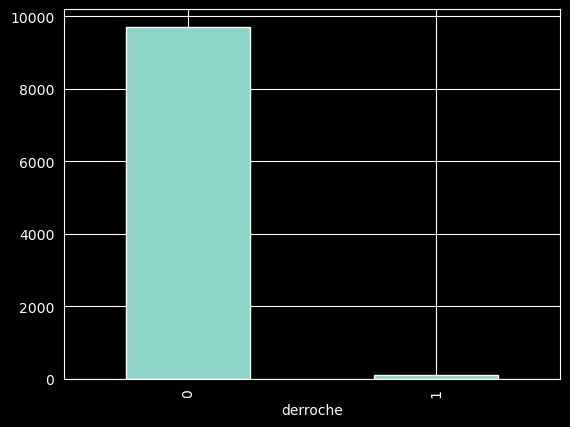

In [7]:
#plot derroche distribution
df["derroche"].value_counts().plot(kind="bar")

In [8]:
# Target (siguiente hora)

df["derroche_next_hour"] = df["derroche"].shift(-1)

# Quitamos las columnas que hemos usado para el target

drop_cols = [
    "open_seconds",
    "derroche",
    "percent_open_time",
    "open_flag",
    "weekday"
]
#drop columns
df = df.dropna(subset=["derroche_next_hour"])
df_model = df.drop(columns=drop_cols)

df_model = df_model.dropna()

In [9]:
df_model

,timestamp,temperature_sensor,humidity_sensor,direccion_viento,humedad,presion,temperatura,viento,date,hour,calefaccion_on,daynight,azimuth,elevation,day_of_week,month,derroche_next_hour
906,2025-01-17 12:00:00+00:00,20.8,56.25,19.0,75.0,1028.0,10.6,34.2,2025-01-17,12,0.0,1.0,184.85,29.62,4,1,0
907,2025-01-17 13:00:00+00:00,19.6,56.05,31.7,63.0,1027.6,11.9,40.0,2025-01-17,13,0.0,1.0,200.96,26.98,4,1,0
908,2025-01-17 14:00:00+00:00,18.5,51.76,34.6,61.0,1027.3,11.9,42.8,2025-01-17,14,1.0,1.0,215.14,21.56,4,1,0
909,2025-01-17 15:00:00+00:00,18.2,49.80,32.5,62.0,1027.5,11.8,39.2,2025-01-17,15,1.0,1.0,227.51,13.96,4,1,0
910,2025-01-17 16:00:00+00:00,18.9,47.78,27.5,60.5,1027.6,11.7,37.4,2025-01-17,16,1.0,1.0,237.97,5.15,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10713,2026-03-02 03:00:00+00:00,18.1,53.46,313.4,93.0,1020.9,9.6,7.2,2026-03-02,3,0.0,0.0,67.79,-34.87,0,3,0
10714,2026-03-02 04:00:00+00:00,18.0,53.44,329.4,94.0,1020.6,9.1,6.1,2026-03-02,4,0.0,0.0,79.25,-23.77,0,3,0
10715,2026-03-02 05:00:00+00:00,17.9,53.63,319.5,93.0,1020.6,9.2,5.8,2026-03-02,5,0.0,0.0,88.86,-12.68,0,3,0
10716,2026-03-02 06:00:00+00:00,18.0,53.51,322.9,90.0,1020.6,9.4,6.8,2026-03-02,6,0.0,1.0,99.23,0.13,0,3,0


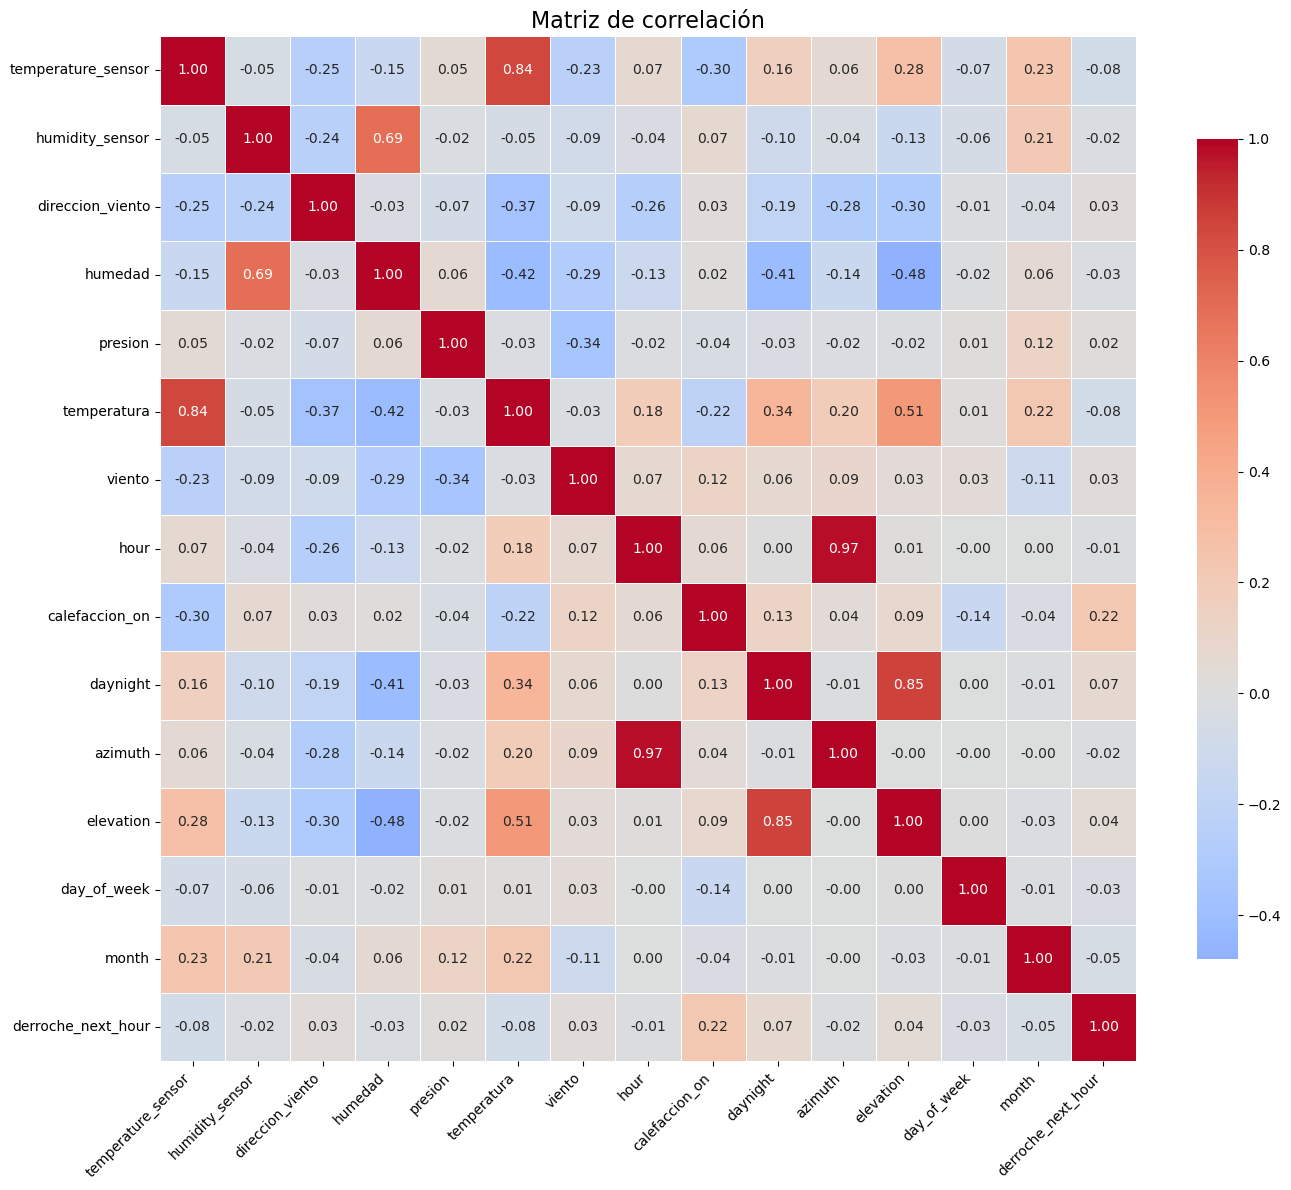

In [10]:
df_corr = df_model.copy()

df_corr["derroche_next_hour"] = df_corr["derroche_next_hour"].astype(int)

df_corr = df_corr.drop(columns=["timestamp", "date"])

import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('default')

# Correlación
corr = df_corr.corr()

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr,
    annot=True,          # mostrar valores
    fmt=".2f",           # 2 decimales
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=False,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de correlación", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [11]:
corr_target = corr["derroche_next_hour"].sort_values(ascending=False)
print(corr_target)

derroche_next_hour    1.000000
calefaccion_on        0.222918
daynight              0.068679
elevation             0.042254
viento                0.028850
direccion_viento      0.027662
presion               0.015834
hour                 -0.014846
azimuth              -0.016509
humidity_sensor      -0.024639
humedad              -0.027325
day_of_week          -0.032860
month                -0.046120
temperature_sensor   -0.076596
temperatura          -0.083389
Name: derroche_next_hour, dtype: float64


In [12]:
print(corr)

                    temperature_sensor  humidity_sensor  direccion_viento  \
temperature_sensor            1.000000        -0.046938         -0.247880   
humidity_sensor              -0.046938         1.000000         -0.242928   
direccion_viento             -0.247880        -0.242928          1.000000   
humedad                      -0.148348         0.688383         -0.034727   
presion                       0.052115        -0.022503         -0.073483   
temperatura                   0.836378        -0.052226         -0.372358   
viento                       -0.233136        -0.087088         -0.093114   
hour                          0.065822        -0.036323         -0.257372   
calefaccion_on               -0.299577         0.066009          0.027308   
daynight                      0.156852        -0.101291         -0.190337   
azimuth                       0.063886        -0.042265         -0.275907   
elevation                     0.281133        -0.133563         -0.295240   

In [13]:
import numpy as np
import pandas as pd

# ============================================
# 1. COPIA Y LIMPIEZA INICIAL
# ============================================

df_nn = df_model.copy()

# Eliminamos timestamp y date no aportan al modelo
df_nn = df_nn.drop(columns=["timestamp", "date"])

# Convertimos target a int
df_nn["derroche_next_hour"] = df_nn["derroche_next_hour"].astype(int)

# Eliminar las columnas redundantes

# Tras la correlación observamos que hay una alta correlacion entre azimuth y hour y entre daynight y elevation.
# por lo que eliminamos las variables redundantes.
# Hay otras variables que correlacionan de forma alta pero son importante para el modelo por su significado.
# azimuth ≈ hour → redundante
# daynight ≈ elevation → redundante
df_nn = df_nn.drop(columns=["azimuth", "daynight"])


# FEATURE ENGINEERING

#podemos generar variables nuevas a partir de las existentes para mejorar el modelo en cuanto a la eficiencia energética.
# Diferencia de temperatura (clave para eficiencia energética)
df_nn["temp_diff"] = df_nn["temperature_sensor"] - df_nn["temperatura"]

# Diferencia de humedad
df_nn["humidity_diff"] = df_nn["humidity_sensor"] - df_nn["humedad"]

#Se ha incorporado la variable diferencia de temperatura y humedad (interior − exterior) como feature adicional. No se han eliminado las variables originales, ya que la diferencia no contiene toda la información de estas, sino que aporta una perspectiva complementaria relevante para la detección de derroche energético.

# HORA Y SEMANA convertimos el formato

# Las variables temporales se han transformado mediante funciones seno y coseno para representar su naturaleza cíclica, permitiendo a la red neuronal capturar patrones periódicos en el uso del aula.
# Las variables temporales como la hora del día y el día de la semana presentan un comportamiento cíclico, es decir, sus valores se repiten de forma periódica (cada 24 horas y cada 7 días respectivamente).

# Sin embargo, si se utilizan directamente como valores numéricos enteros, el modelo interpreta que la distancia entre valores es lineal. Por ejemplo, considera que la hora 23 está muy alejada de la hora 0, cuando en realidad son momentos consecutivos.

# Para evitar este problema, se transforman estas variables mediante funciones seno y coseno, proyectándolas en un espacio circular. De este modo, se preserva la naturaleza cíclica del tiempo, ya que valores cercanos en el ciclo (como 23 y 0) también quedan próximos en la representación.

# Esta transformación permite a la red neuronal capturar patrones periódicos en el comportamiento del aula, como diferencias entre mañanas y tardes o entre días laborables y fines de semana, mejorando así su capacidad de generalización.

# Hora (0–23)
df_nn["hour_sin"] = np.sin(2 * np.pi * df_nn["hour"] / 24)
df_nn["hour_cos"] = np.cos(2 * np.pi * df_nn["hour"] / 24)

# Día de la semana (0–6)
df_nn["dow_sin"] = np.sin(2 * np.pi * df_nn["day_of_week"] / 7)
df_nn["dow_cos"] = np.cos(2 * np.pi * df_nn["day_of_week"] / 7)

# Eliminamos variables originales (ya codificadas mejor)
df_nn = df_nn.drop(columns=["hour", "day_of_week"])

# Seleccionamos solo las que vamos a usar para entrenar

features = [
    "calefaccion_on",
    "temperature_sensor",
    "temperatura",
    "temp_diff",
    "humidity_sensor",
    "humedad",
    "humidity_diff",
    "viento",
    "direccion_viento",
    "elevation",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

target = "derroche_next_hour"

X = df_nn[features]
y = df_nn[target]

print("Shape X:", X.shape)



Shape X: (8486, 14)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import os
import json
import joblib
import warnings

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, confusion_matrix, classification_report


# SPLIT + SCALING

def prepare_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


# CLASS WEIGHTS
# Calcula pesos para cada clase (0 y 1) en función de cuántas muestras hay.
# El dataset está muy desbalanceado asi que para mejorar el entrenamiento
# Debido al desbalanceo del dataset, donde la clase de derroche es minoritaria, se emplea class_weight='balanced' para asignar mayor peso a esta clase durante el entrenamiento. Esto permite penalizar más los errores asociados a eventos de derroche, evitando que el modelo se sesgue hacia la clase mayoritaria y mejorando su capacidad de generalización en la detección de casos poco frecuentes.
# Esta técnica es especialmente relevante en problemas desbalanceados, donde métricas como la accuracy pueden resultar engañosas, y se prioriza mejorar el recall y el F1-score de la clase minoritaria.

def compute_weights(y_train):
    classes = np.unique(y_train)
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=y_train
    )
    return dict(zip(classes, weights))


def build_model(input_dim, architecture):
    model = Sequential()

    for i, units in enumerate(architecture):
        if i == 0:
            model.add(Dense(units, activation="relu", input_shape=(input_dim,)))
        elif i == len(architecture) - 1:
            model.add(Dense(1, activation="sigmoid"))
        else:
            model.add(Dense(units, activation="relu"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model


def train_model(model, X_train, y_train, class_weights):
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.3,
        epochs=50,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stopping],
        verbose=1
    )

    return history



def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test, verbose=0)

    thresholds = np.arange(0.01, 0.99, 0.01)
    f1_scores = []

    for t in thresholds:
        y_pred_t = (y_pred_prob > t).astype(int)
        f1_scores.append(f1_score(y_test, y_pred_t))

    best_idx = np.argmax(f1_scores)
    best_t = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    y_pred = (y_pred_prob > best_t).astype(int)

    return best_t, best_f1, y_pred, y_pred_prob, thresholds, f1_scores


# GUARDAR MODELO COMPLETO

def save_full_model(model, scaler, arch, threshold, f1, features):

    base_path = "../../data/lake/silver/models/"
    os.makedirs(base_path, exist_ok=True)

    arch_name = "_".join(map(str, arch))
    model_dir = os.path.join(base_path, f"model_{arch_name}")
    os.makedirs(model_dir, exist_ok=True)

    model.save(os.path.join(model_dir, "model.keras"))
    model.save(os.path.join(model_dir, "model_compat.h5"))
    joblib.dump(scaler, os.path.join(model_dir, "scaler.pkl"))

    config = {
        "architecture": arch,
        "threshold": float(threshold),
        "f1_score": float(f1),
        "tensorflow_version": tf.__version__,
        "keras_version": keras.__version__,
        "numpy_version": np.__version__,
        "features": list(features)
    }

    with open(os.path.join(model_dir, "config.json"), "w", encoding="utf-8") as f:
        json.dump(config, f, indent=4)

    print(f"Modelo guardado en: {model_dir}")


def print_results(y_test, y_pred, best_t, best_f1):
    print(f"\nBest threshold: {best_t:.2f}")
    print(f"Best F1-score: {best_f1:.4f}")

    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))


def plot_history(history, row, architecture, num_models, max_epochs):
    metrics = ["loss", "accuracy", "precision", "recall"]
    history_dict = history.history
    epochs = range(1, len(history_dict["loss"]) + 1)

    all_values = []
    for m in metrics:
        all_values += history_dict[m]
        all_values += history_dict["val_" + m]

    y_min = min(all_values)
    y_max = max(all_values)

    for col, m in enumerate(metrics):
        plt.subplot(num_models, 4, row*4 + col + 1)

        plt.plot(epochs, history_dict[m], label="train")
        plt.plot(epochs, history_dict["val_" + m], label="val")

        plt.title(f"{architecture} - {m}")
        plt.ylim(y_min, y_max)
        plt.xlim(1, max_epochs)
        plt.legend(fontsize=7)


def plot_f1_threshold(results):
    plt.figure(figsize=(8, 6))

    for r in results:
        plt.plot(r["thresholds"], r["f1_scores"], label=str(r["arch"]))

    plt.xlabel("Threshold")
    plt.ylabel("F1-score")
    plt.title("F1-score vs Threshold")
    plt.legend()
    plt.grid()
    plt.show()


def plot_f1_models(results):
    f1s = [r["best_f1"] for r in results]
    labels = [str(r["arch"]) for r in results]

    plt.figure(figsize=(8, 5))
    plt.barh(labels, f1s)

    plt.xlabel("F1-score")
    plt.title("Comparación de modelos")
    plt.grid(axis="x")

    plt.show()


def run_training(X, y, architectures):
    X_train, X_test, y_train, y_test, scaler = prepare_data(X, y)
    class_weights = compute_weights(y_train)

    results = []
    for arch in architectures:
        print("\n" + "="*60)
        print(f"ENTRENANDO: {arch}")
        print("="*60)

        model = build_model(X_train.shape[1], arch)
        history = train_model(model, X_train, y_train, class_weights)

        best_t, best_f1, y_pred, y_pred_prob, thresholds, f1_scores = evaluate_model(
            model, X_test, y_test
        )

        save_full_model(model, scaler, arch, best_t, best_f1, features)

        results.append({
            "arch": arch,
            "history": history,
            "y_pred": y_pred,
            "best_t": best_t,
            "best_f1": best_f1,
            "thresholds": thresholds,
            "f1_scores": f1_scores
        })

    print("\n✅ Entrenamiento completado.")
    return results, y_test


def show_results(results, y_test):
    num_models = len(results)
    max_epochs = max(len(r["history"].history["loss"]) for r in results)

    # TEXTO
    for r in results:
        print("\n" + "="*60)
        print(f"ARQUITECTURA: {r['arch']}")
        print("="*60)
        print_results(y_test, r["y_pred"], r["best_t"], r["best_f1"])

    # GRÁFICAS TRAINING
    plt.figure(figsize=(16, 5 * num_models))
    for i, r in enumerate(results):
        plot_history(r["history"], i, r["arch"], num_models, max_epochs)

    plt.tight_layout()
    plt.show()

    # F1
    plot_f1_threshold(results)
    plot_f1_models(results)


2026-03-24 18:28:34.147906: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 18:28:34.212006: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-24 18:28:35.700539: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [15]:
architectures = [
    [16, 1],
    [32, 16, 1],
    [64, 32, 16, 1],
    [128, 64, 32, 1],
    [64, 32, 16, 8, 1],
    [32, 64, 32, 16, 1],
    [128, 32, 1]
]

results, y_test = run_training(X, y, architectures)



ENTRENANDO: [16, 1]


/home/jevallo/anaconda3/envs/tensorflow/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774373319.604728   52682 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5781 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0


Epoch 1/50


2026-03-24 18:28:41.243364: I external/local_xla/xla/service/service.cc:153] XLA service 0x738370014a60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-24 18:28:41.243406: I external/local_xla/xla/service/service.cc:161]   StreamExecutor device (0): NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0
2026-03-24 18:28:41.278626: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774373321.426034   52944 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-24 18:28:41.446144: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-24 18:28:41.446184: W external/local_xla/xla/ser

 31/149 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5258 - loss: 0.4963 - precision: 0.0027 - recall: 0.2015

...

149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8488 - loss: 0.6460 - precision: 0.0472 - recall: 0.4978

2026-03-24 18:32:34.550966: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-24 18:32:35.510557: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_50', 92 bytes spill stores, 92 bytes spill loads

2026-03-24 18:32:35.807260: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_50', 92 bytes spill stores, 92 bytes spill loads

2026-03-24 18:32:35.807433: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_50', 176 bytes sp

149/149 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.8857 - loss: 0.4454 - precision: 0.0656 - recall: 0.6981 - val_accuracy: 0.9097 - val_loss: 0.2828 - val_precision: 0.0905 - val_recall: 0.8571
Epoch 2/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9044 - loss: 0.2342 - precision: 0.0966 - recall: 0.9057 - val_accuracy: 0.8508 - val_loss: 0.3389 - val_precision: 0.0592 - val_recall: 0.9048
Epoch 3/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9185 - loss: 0.1815 - precision: 0.1187 - recall: 0.9811 - val_accuracy: 0.8557 - val_loss: 0.3414 - val_precision: 0.0639 - val_recall: 0.9524
Epoch 4/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9270 - loss: 0.1413 - precision: 0.1325 - recall: 1.0000 - val_accuracy: 0.8635 - val_loss: 0.3432 - val_precision: 0.0673 - val_recall: 0.9524
Epoch 5/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9356 - loss: 0.1201 - precision: 0.1476 - recall: 1.0000 - val_accuracy: 0.8645 - val_loss: 0.3798 - va

2026-03-24 18:32:40.406653: W external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-24 18:32:41.470739: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 92 bytes spill stores, 92 bytes spill loads

2026-03-24 18:32:41.515316: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 92 bytes spill stores, 92 bytes spill loads

2026-03-24 18:32:41.540387: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 84 bytes spi

Modelo guardado en: ../../data/lake/silver/models/model_128_32_1

✅ Entrenamiento completado.



ARQUITECTURA: [16, 1]

Best threshold: 0.81
Best F1-score: 0.1333

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.84      0.91      1673
           1       0.07      0.84      0.13        25

    accuracy                           0.84      1698
   macro avg       0.53      0.84      0.52      1698
weighted avg       0.98      0.84      0.90      1698


Confusion matrix:
[[1404  269]
 [   4   21]]

ARQUITECTURA: [32, 16, 1]

Best threshold: 0.94
Best F1-score: 0.1587

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1673
           1       0.10      0.40      0.16        25

    accuracy                           0.94      1698
   macro avg       0.54      0.67      0.56      1698
weighted avg       0.98      0.94      0.96      1698


Confusion matrix:
[[1582   91]
 [  15   10]]

ARQUITECTURA: [64, 32, 16, 1]

Best threshold: 0.89
Best F1-score: 

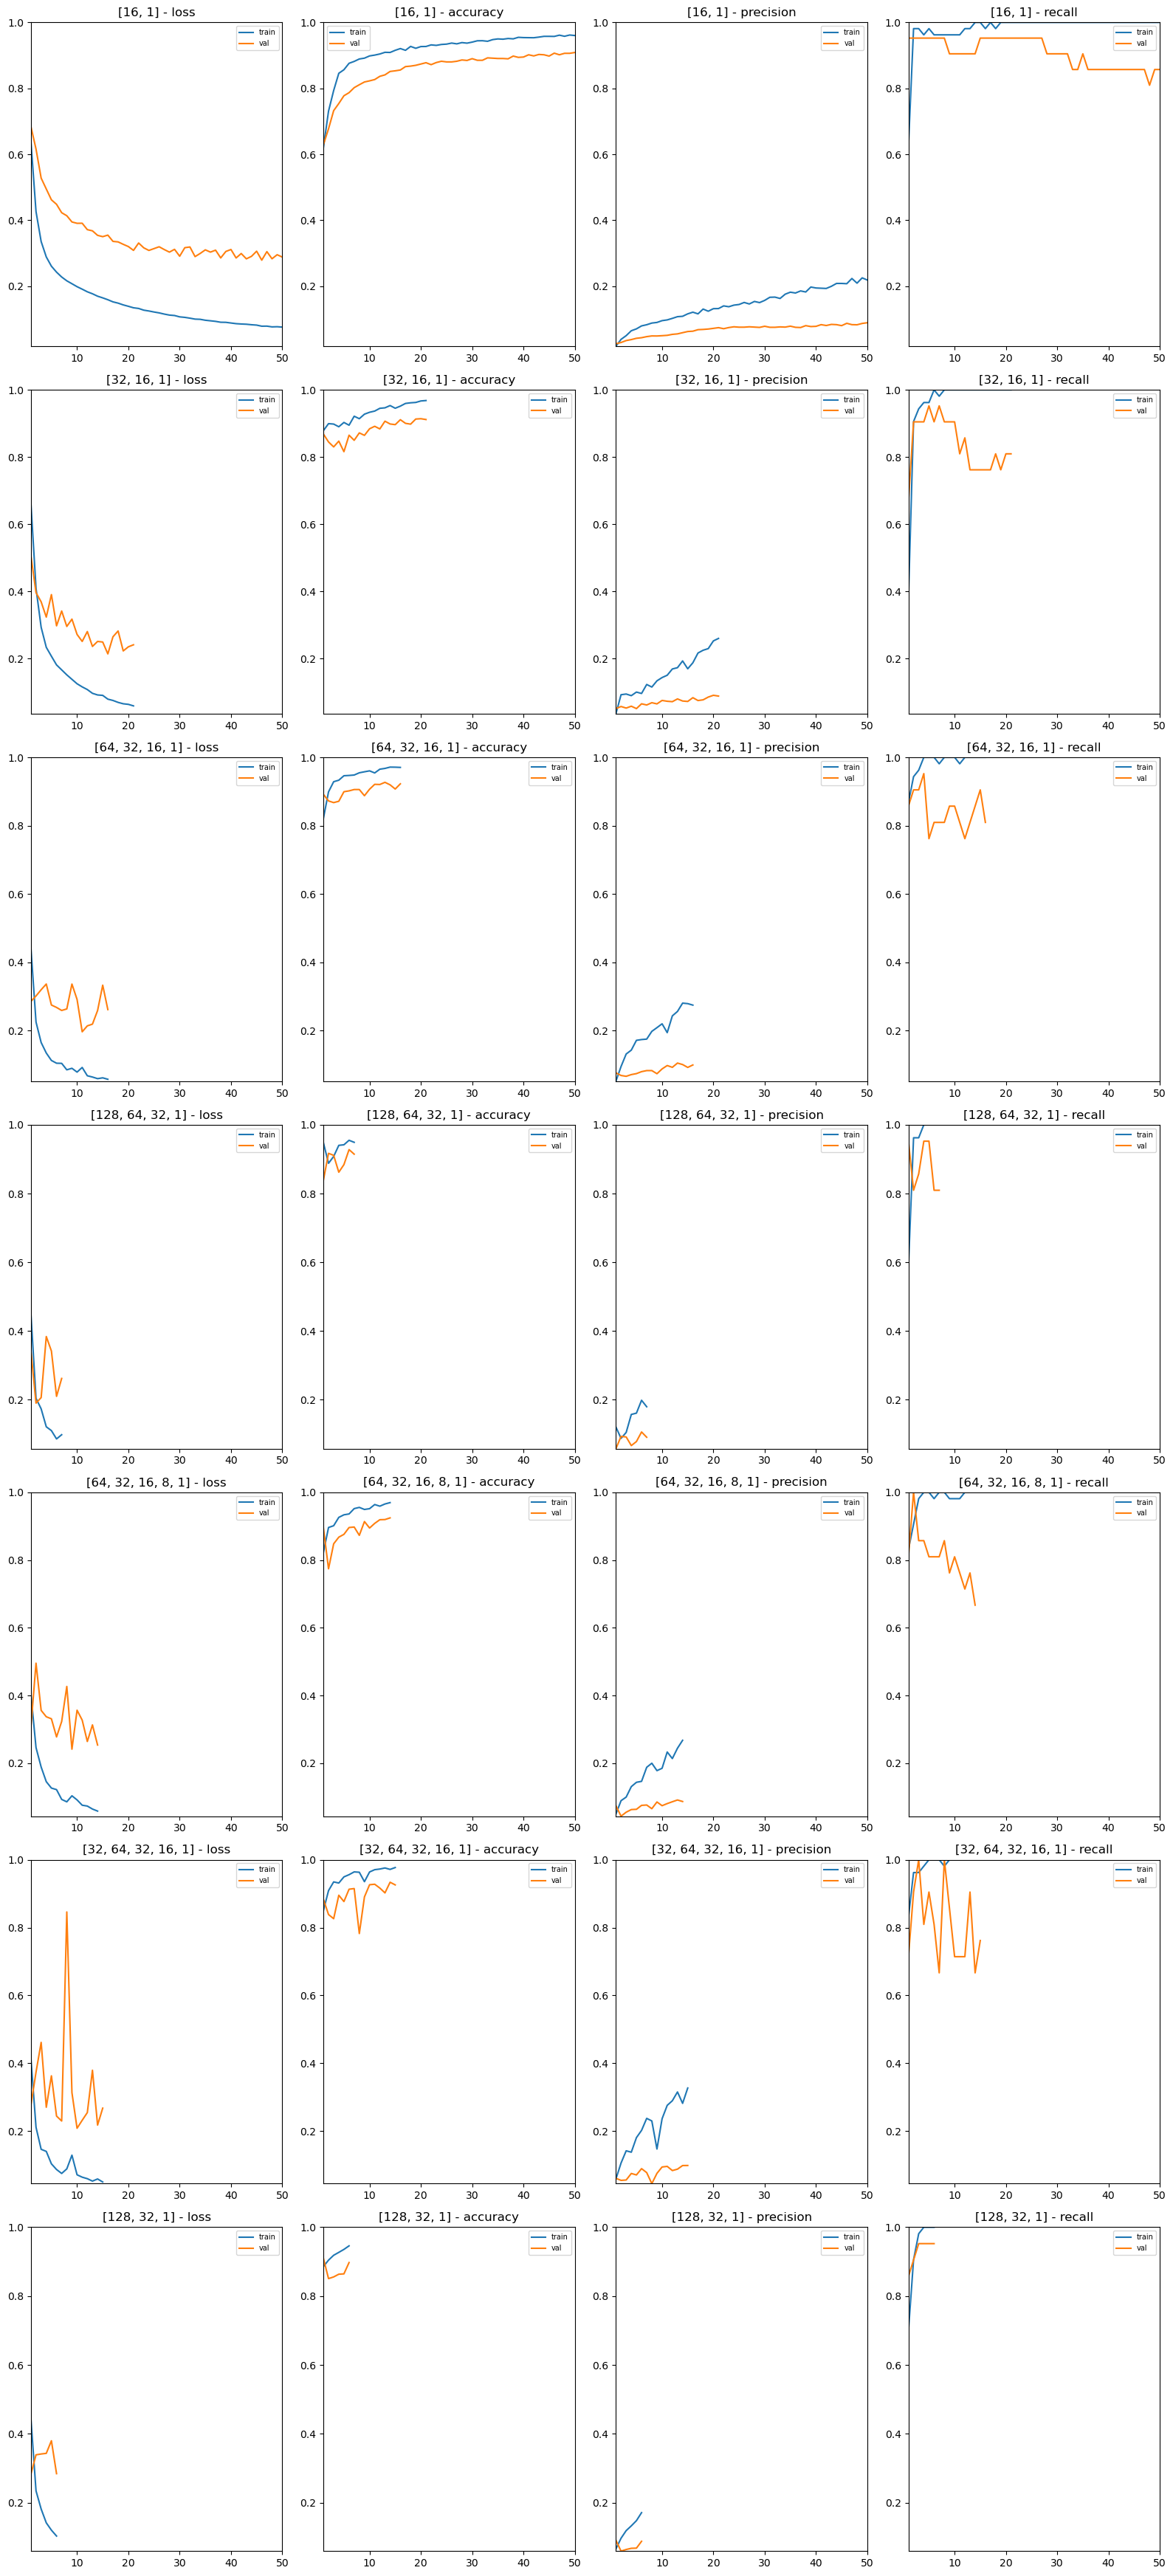

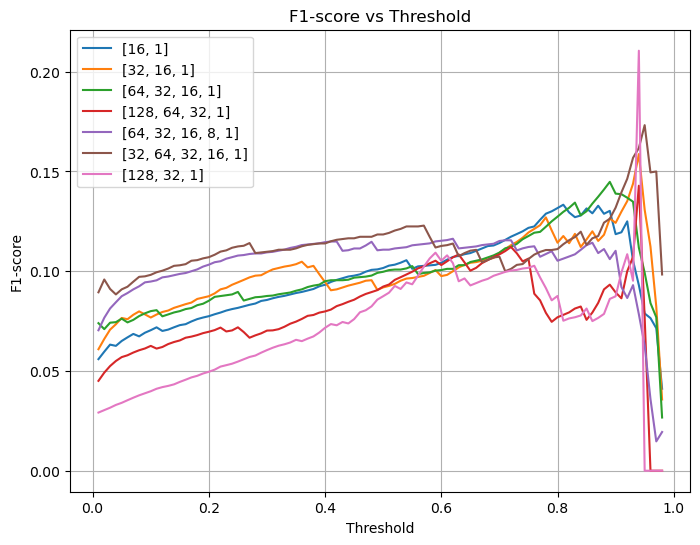

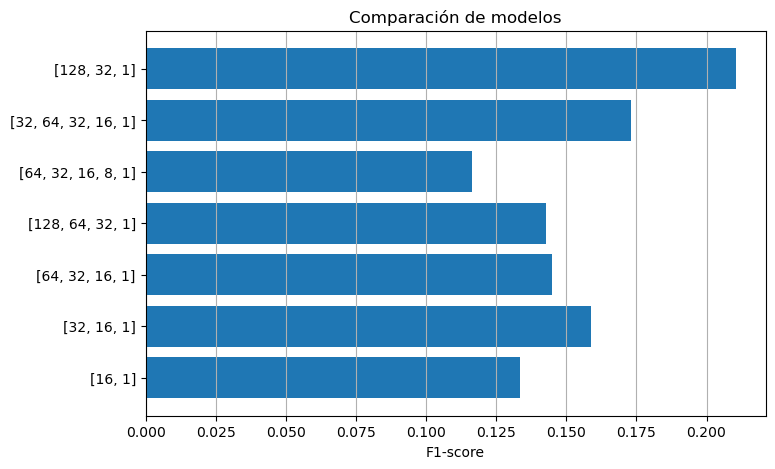

In [16]:
show_results(results, y_test)

# Selección del modelo de red neuronal

| Modelo          | TP     | FN    | FP    | Recall      | Precision |
| --------------- | ------ | ----- | ----- | ----------- | --------- |
| [16,1]          | **21** | **4** | 269   | **0.84** 🔥 | 0.07      |
| [64,32,16,8,1]  | 20     | 5     | 299   | 0.80        | 0.06      |
| [64,32,16,1]    | 16     | 9     | 180   | 0.64        | 0.08      |
| [32,64,32,16,1] | 11     | 14    | 91    | 0.44        | 0.11      |
| [32,16,1]       | 10     | 15    | 91    | 0.40        | 0.10      |
| [128,64,32,1]   | 6      | 19    | 53    | 0.24        | 0.10      |
| [128,32,1]      | 4      | 21    | **9** | 0.16        | **0.31**  |

Dado que el objetivo del sistema es detectar situaciones de derroche energético, se prioriza un mayor recall.

Se observan tres comportamientos diferenciados:

### Modelos con alto recall
- [16,1]
- [64,32,16,8,1]

Detectan la mayoría de los derroches, pero generan un número muy elevado de falsos positivos, lo que puede afectar a la usabilidad del sistema.

---

### Modelos equilibrados
- [64,32,16,1]
- [32,64,32,16,1]
- [32,16,1]

Presentan un mejor compromiso entre recall y precisión, reduciendo los falsos positivos sin dejar de detectar una parte significativa de los derroches.

---

### Modelos conservadores
- [128,32,1]
- [128,64,32,1]

Tienen métricas globales altas (accuracy, F1), pero un recall muy bajo, por lo que no resultan adecuados para este problema.

---

El modelo [16, 1] consigue el mayor recall (0.84), detectando 21 de los 25 casos de derroche y minimizando los falsos negativos. Sin embargo, genera un número elevado de falsos positivos (269), lo que puede provocar un exceso de alertas.

Por otro lado, el modelo [32, 64, 32, 16, 1] ofrece un mejor equilibrio entre recall (0.44) y precisión (0.11), reduciendo significativamente los falsos positivos (91), aunque detecta menos casos de derroche.

La elección del modelo depende del coste asociado a los errores:

- Si se prioriza **no perder derroches (minimizar FN)** → se selecciona el modelo **[16, 1]**
- Si se busca un sistema más **equilibrado y usable** → se selecciona el modelo **[32, 64, 32, 16, 1]**
